# Important to run this notebook
A `.env` file at the root of this repository that defines `PYTHONPATH=src/python` is required to have the correct module resolution.

In [9]:
from typing import Literal
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
from matplotlib.axes import Axes
from results import Result
import os

plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        #'font.serif': ['Latin Modern Roman'],  # Replace with the specific font used in your beamer poster
        #'font.sans-serif': ['Latin Modern Sans'],
        "font.size": 10,  # in beamer
    }
)

LEGEND = {
    "ucb": "UCB",
    "egreedy": "$\\epsilon$-greedy",
    "epsilongreedy": "$\\epsilon$-greedy",
    "random": "Random",
    "ppo": "PPO",
    "dqn": "DQN",
    "bestslopefirst": "BSF",
    "roundrobin": "RR",
}
LEGEND_ORDER = ["PPO", "DQN", "UCB", "$\\epsilon$-greedy", "Random", "BSF", "RR"]
COLOURS = {
    "ppo": "C0",
    "dqn": "C1",
    "egreedy": "C2",
    "epsilongreedy": "C2",
    "random": "C3",
    "ucb": "C4",
    "bestslopefirst": "C5",
    "roundrobin": "C6",
}
LINE_STYLES = {"r1": "dashed", "r2": "solid", "r3": "dotted", "None": "dashdot"}


def load(problem: Literal["csp", "csp_1h30", "tsp", "pdptw"]):
    dfs = list[pl.DataFrame]()
    for csv in os.listdir(os.path.join("results", problem)):
        csv = os.path.join("results", problem, csv)
        df = pl.read_csv(csv)
        # if problem not in ("csp_1h30", "csp"): 
        #     df  = df.with_columns(
        #     (
        #         pl.when(
        #             pl.col("bandit").is_in(
        #                 [
        #                     "ucb",
        #                     "epsilongreedy",
        #                     "egreedy",
        #                 ]
        #             )
        #             & (pl.col("reward") == "r2")
        #         )
        #         .then(pl.lit("r3"))
        #         .otherwise(pl.col("reward"))
        #         .alias("reward")
        #     )
        # )
        dfs.append(df)
    return (
        pl.concat(dfs, how="diagonal")
        .drop("a", strict=False)
        .filter(pl.col("solOverTime").str.len_chars() > 2)
        .with_columns(instance_size=pl.col("instance").str.split("/").list.get(2))
    )


def cm_to_inch(cm):
    """
    for a more civilized age
    """
    return cm / 2.54


def compute_xmax(results: list[Result], by: Literal["time", "step"] = "time"):
    if by == "time":
        return max(r.t_max for r in results)
    elif by == "step":
        return max(r.step_max for r in results)
    else:
        raise ValueError(f"Unknown by value: {by}")


def compute_primal_gaps(results: list[Result], by: Literal["time", "step"] = "time"):
    tmax = int(compute_xmax(results, by=by) + 1)
    objs = [r.primal_gap_array(by=by, tmax=tmax) for r in results]
    return np.array(objs, dtype=np.float32)


def compute_objectives(results: list[Result], by: Literal["time", "step"] = "time"):
    tmax = int(compute_xmax(results, by=by) + 1)
    objs = [r.objective_array(by=by, tmax=tmax) for r in results]
    return np.array(objs, dtype=np.float32)


def plot_by_bandit_and_reward(
    df: pl.DataFrame,
    ax: Axes,
    metric: Literal["primal gap", "objective"] = "primal gap",
    auto_ylim: bool = True,
    x_axis: Literal["time", "step"] = "time",
    y_label: bool = False,
    xmax: int | None = None,
    show_ci95: bool = True,
):
    ymin, ymax = float("inf"), float("-inf")
    if xmax is None:
        xmax = 0
    data = dict[tuple[str, str], tuple[np.ndarray, np.ndarray]]()
    for (bandit, reward), bandit_df in df.group_by(pl.col("bandit"), pl.col("reward")):
        print(f"Processing {bandit} ({bandit_df.height} results)")
        results = [Result(**row) for row in bandit_df.iter_rows(named=True)]
        match metric:
            case "primal gap":
                arr = compute_primal_gaps(results, by=x_axis) * 100
            case "objective":
                arr = compute_objectives(results, by=x_axis)
            case other:
                raise ValueError(f"Unknown metric {other}")
        mean, std = arr.mean(axis=0), arr.std(axis=0)
        ci95 = 1.96 * std / len(results) ** 0.5
        xmax = max(xmax, len(mean))
        if auto_ylim:
            istart = int(-len(mean) // 5)
            if show_ci95:
                ymin = min(ymin, (mean[istart:] - ci95[istart:]).min())
                ymax = max(ymax, (mean[istart:] + ci95[istart:]).max())
            else:
                ymin = min(ymin, mean[istart:].min())
                ymax = max(ymax, mean[istart:].max())
        data[bandit, reward] = (mean, ci95)

    xs = np.arange(xmax)
    for (bandit, reward), (mean, ci95) in data.items():
        if bandit in ["random", "roundrobin", "bestslopefirst"]:
            linestyle = LINE_STYLES["None"]
        else:
            linestyle = LINE_STYLES[reward]
        mean = np.concat([mean, np.full(xmax - len(mean), mean[-1])])
        ax.plot(xs, mean, label=LEGEND[bandit], color=COLOURS[bandit], linestyle=linestyle)
        if show_ci95:
            ci95 = np.concat([ci95, np.full(xmax - len(ci95), ci95[-1])])
            ax.fill_between(xs, mean - ci95, mean + ci95, alpha=0.2)
    if x_axis == "time":
        ax.set_xlabel("Time (s)")
    elif x_axis == "step":
        ax.set_xlabel("Steps")
    if y_label:
        match metric:
            case "primal gap":
                ax.set_ylabel(r"Primal Gap (\%)")
            case "objective":
                ax.set_ylabel("Objective")
    ax.margins(x=0.01, y=0.01)
    ax.grid(axis="y")
    if auto_ylim:
        ax.set_ylim(ymin * 0.95, ymax * 1.05)
    ax.set_title(results[0].problem.upper(), loc="center")
    # handles, labels = ax.get_legend_handles_labels()
    # labels, handles = zip(*sorted(zip(labels, handles), key=lambda x: LEGEND_OR£DER.index(x[0])))
    # ax.legend(handles, labels, loc="upper right")

# Global plot with 3 problems

Processing ucb (880 results)
Processing epsilongreedy (880 results)
Processing ppo (427 results)
Processing dqn (702 results)
Processing random (880 results)
Processing ppo (233 results)
Processing epsilongreedy (880 results)
Processing bestslopefirst (880 results)
Processing ucb (880 results)
Processing dqn (1041 results)
Processing roundrobin (880 results)
Processing epsilongreedy (390 results)
Processing ucb (390 results)
Processing ppo (195 results)
Processing dqn (189 results)
Processing epsilongreedy (390 results)
Processing bestslopefirst (390 results)
Processing random (390 results)
Processing dqn (160 results)
Processing ppo (96 results)
Processing roundrobin (390 results)
Processing ucb (390 results)
Processing epsilongreedy (420 results)
Processing random (1260 results)
Processing ppo (1265 results)
Processing dqn (840 results)
Processing roundrobin (121 results)
Processing bestslopefirst (753 results)
Processing ucb (293 results)


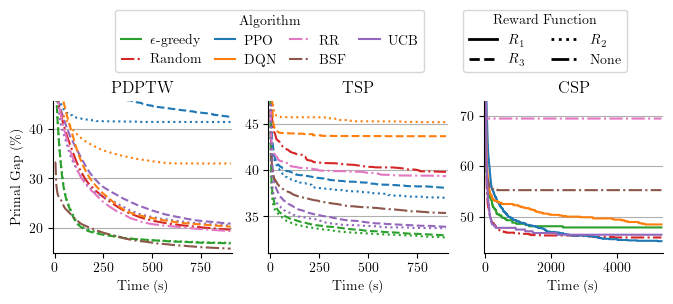

In [12]:
from matplotlib.lines import Line2D

figsize = (cm_to_inch(20), cm_to_inch(5))
fig, axes = plt.subplots(1, 3, sharex=False, figsize=figsize)
for i, problem in enumerate(("pdptw", "tsp", "csp_1h30")):
    ax = axes[i]
    df_problem = load(problem)
    plot_by_bandit_and_reward(df_problem, ax=ax, metric="primal gap", x_axis="time", show_ci95=False, y_label=(i == 0))
    # Remove the outer frame (spines)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # plt.ylim(9500, 12500)

handles, labels = axes[-1].get_legend_handles_labels()
legend_algo = fig.legend(
    handles,
    labels,
    title="Algorithm",
    bbox_to_anchor=(0.4, 1.38),
    loc="upper center",
    ncol=4,
    handlelength=1.5,
    columnspacing=1,
    handletextpad=0.6,
)

lines = [Line2D([0], [0], color="black", lw=2, linestyle=LINE_STYLES[ls]) for ls in ["r2", "r1", "r3", "None"]]
legend_rewards = fig.legend(
    lines,
    [r"$R_1$", r"$R_3$", r"$R_2$", "None"],
    title="Reward Function",
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.75, 1.38),
)


fig.savefig(
    "plot.pdf",
    bbox_inches="tight",
    bbox_extra_artists=(legend_algo, legend_rewards),  # helps some backends include the legend
    pad_inches=0.05,
)

<Axes: xlabel='instance_size', ylabel='bestObj'>

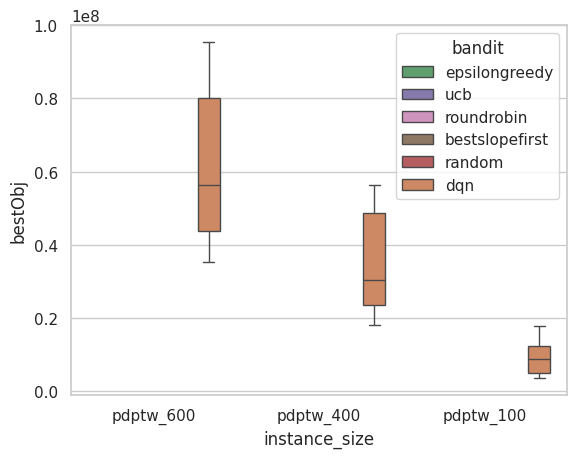

In [5]:
import seaborn as sns

sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df,
    x="instance_size",
    y="bestObj",
    hue="bandit",
    palette=COLOURS,
    formatter=lambda label: LEGEND.get(label, label), # type: ignore
)